In [1]:
import os
import unidecode
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from app.config import (
    PROJ_ROOT,
    RAW_DATA_DIR,
)

2026-02-24 22:18:49.692 | INFO     | app.config:<module>:11 - PROJ_ROOT path is: D:\CEDS\tcc\CEDS-TCC


In [3]:
os.listdir(RAW_DATA_DIR)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [4]:
dfs = {}

for file in os.listdir(RAW_DATA_DIR):
    if file.endswith(".csv"):
        file_path = os.path.join(RAW_DATA_DIR, file)
        dfs[file.replace(".csv", "")] = pd.read_csv(file_path)

## Dataset de Geoloc

Mexendo com zip code (prefixo do CEP). Obtém-se `geolocation_lat` e `geolocation_lng` médios, somente. Irá ser aproveitado a cidade e estado da tabela de costumer, pois está melhor tratada.

In [5]:
df = (
    dfs['olist_geolocation_dataset']
    .groupby(["geolocation_zip_code_prefix"])
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean"
    })
    .reset_index()
)

df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


## Dataset de Customers

In [52]:
dfs['olist_customers_dataset']

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


Note que, mesmo tratando as cidades da coluna `customer_city`, a quantidade de valores únicos se mantém, apresentando que tais valores já estão devidamente tratados. 

In [47]:
dfs['olist_customers_dataset'].customer_city.nunique()

4119

In [ ]:
(
    dfs['olist_customers_dataset']
    .customer_city
    .str.lower()
    .str.strip()
    .apply(unidecode.unidecode)
    .nunique()
)

4119

In [ ]:
city_counts = (
    dfs['olist_customers_dataset']
    .customer_city
    .value_counts()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

rank = range(1, len(city_counts) + 1)

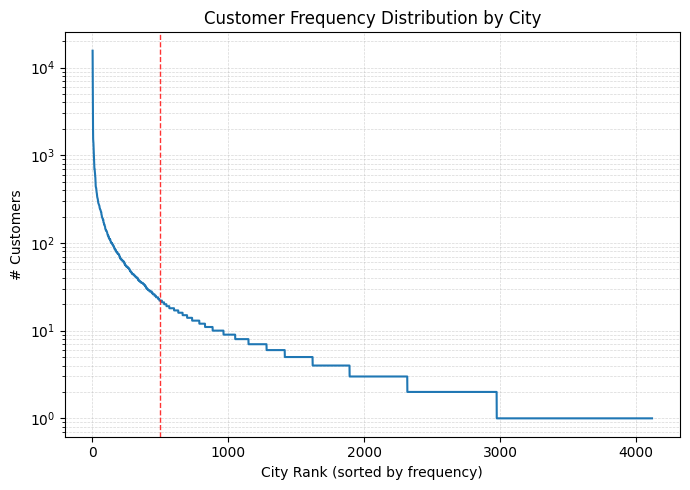

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.lineplot(x=rank, y=city_counts)

ax.set_yscale("log")

ax.axvline(
    x=500,
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    color='red'
)

ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

ax.set_xlabel("City Rank (sorted by frequency)")
ax.set_ylabel("# Customers")
ax.set_title("Customer Frequency Distribution by City")

plt.tight_layout()
plt.show()

In [58]:
df = dfs['olist_customers_dataset'].merge(
    df,
    left_on = "customer_zip_code_prefix",
    right_on = "geolocation_zip_code_prefix",
    how = "left"
)

df.drop(columns=["geolocation_zip_code_prefix"], inplace=True)
df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.498489,-47.396929
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.727992,-46.542848
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531642,-46.656289
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499702,-46.185233
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975100,-47.142925


## Dataset de Orders

In [66]:
dfs['olist_orders_dataset']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [65]:
dfs['olist_products_dataset']

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [59]:
dfs['olist_order_items_dataset']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [63]:
dfs['olist_products_dataset'].product_category_name.nunique()

73

In [64]:
dfs['product_category_name_translation'].product_category_name.nunique()

71

In [25]:
dfs['olist_orders_dataset'][dfs['olist_orders_dataset'].order_status == 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [ ]:
import pandas as pd

# =============================
# 1. LOAD DATA
# =============================

customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

# =============================
# 2. CUSTOMER FEATURES
# =============================

# Agregar geolocation
geo_agg = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean"
    })
    .reset_index()
)

customers = customers.merge(
    geo_agg,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

customers.drop(columns=["geolocation_zip_code_prefix"], inplace=True)

# =============================
# 3. ORDER ITEMS FEATURES
# =============================

# Merge com produtos
order_items = order_items.merge(
    products,
    on="product_id",
    how="left"
)

# Merge categoria traduzida
order_items = order_items.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Agregar por pedido
items_agg = (
    order_items
    .groupby("order_id")
    .agg({
        "price": ["sum", "mean"],
        "freight_value": ["sum"],
        "product_id": "count",
        "product_weight_g": "mean",
        "product_length_cm": "mean",
        "product_height_cm": "mean",
        "product_width_cm": "mean"
    })
)

items_agg.columns = [
    "total_price",
    "avg_price",
    "total_freight",
    "n_items",
    "avg_weight",
    "avg_length",
    "avg_height",
    "avg_width"
]

items_agg = items_agg.reset_index()

# =============================
# 4. PAYMENT FEATURES
# =============================

payments_agg = (
    order_payments
    .groupby("order_id")
    .agg({
        "payment_value": ["sum", "mean"],
        "payment_installments": "max"
    })
)

payments_agg.columns = [
    "total_payment",
    "avg_payment",
    "max_installments"
]

payments_agg = payments_agg.reset_index()

# =============================
# 5. REVIEW FEATURES
# =============================

reviews_agg = (
    order_reviews
    .groupby("order_id")
    .agg({
        "review_score": "mean"
    })
    .reset_index()
)

# =============================
# 6. BASE TABLE (ORDERS)
# =============================

df = orders.copy()

# Merge customers
df = df.merge(customers, on="customer_id", how="left")

# Merge items
df = df.merge(items_agg, on="order_id", how="left")

# Merge payments
df = df.merge(payments_agg, on="order_id", how="left")

# Merge reviews
df = df.merge(reviews_agg, on="order_id", how="left")

# =============================
# 7. FEATURE ENGINEERING
# =============================

# Converter datas
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Tempo de entrega real
df["delivery_time_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

# Atraso na entrega
df["delay_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days

# Features temporais
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour
df["purchase_weekday"] = df["order_purchase_timestamp"].dt.weekday
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

# =============================
# 8. FINAL DATASET
# =============================

print(df.shape)
df.head()